In [ ]:
!pip install faker

In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
fake = Faker()

In [ ]:
genders = ["Male", "Female"]
departments = ["CSE", "IT", "ECE"]
years = ["1st", "2nd", "3rd"]

data = []

for i in range(1, 251):
    student = {
        "Student_ID": i,
        "Name": fake.name(),
        "Gender": random.choice(genders),
        "Department": random.choice(departments),
        "Year": random.choice(years),
        "Maths": random.randint(0, 100),
        "Science": random.randint(0, 100),
        "English": random.randint(0, 100),
        "Attendance": random.randint(50, 100),
        "Internal_Marks": random.randint(0, 25)
    }
    data.append(student)

df = pd.DataFrame(data)

df.tail()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks
245,246,Megan Shepherd,Male,ECE,1st,72,60,81,56,6
246,247,Catherine Weaver,Male,CSE,1st,37,76,18,67,0
247,248,Kimberly Snyder,Male,ECE,2nd,12,54,61,92,24
248,249,Nancy Hill,Male,ECE,2nd,87,75,18,76,17
249,250,Mark Escobar,Male,CSE,3rd,77,21,26,84,7


In [ ]:
#PREPROCESING
print("Missing Values:\n", df.isnull().sum())

df = df.drop_duplicates()

print("\nDataset Shape:", df.shape)

Missing Values:
 Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
dtype: int64

Dataset Shape: (250, 10)


In [ ]:
df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 80:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 40:
        return "C"
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
0,1,James Villarreal,Male,IT,3rd,13,100,39,70,18,152,50.666667,C
1,2,Robert Buck,Male,IT,3rd,73,68,29,74,11,170,56.666667,C
2,3,Vincent Scott,Female,CSE,1st,27,46,80,61,20,153,51.000000,C
3,4,Jason Thomas,Female,ECE,1st,76,18,10,50,18,104,34.666667,Fail
4,5,Kevin Brown,Female,CSE,3rd,15,37,9,62,11,61,20.333333,Fail


In [ ]:
df.describe()

,Student_ID,Maths,Science,English,Attendance,Internal_Marks,Total,Average
count,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,47.364000,50.84400,50.096000,74.576000,12.596000,148.304000,49.434667
std,72.312977,28.832007,29.82916,29.230815,14.688336,7.594702,50.689023,16.896341
min,1.000000,0.000000,0.00000,0.000000,50.000000,0.000000,21.000000,7.000000
25%,63.250000,23.000000,26.25000,26.000000,62.000000,6.250000,116.250000,38.750000
50%,125.500000,46.500000,53.50000,49.000000,73.500000,12.000000,145.500000,48.500000
75%,187.750000,72.000000,76.75000,75.000000,87.000000,19.000000,182.000000,60.666667
max,250.000000,100.000000,100.00000,100.000000,100.000000,25.000000,283.000000,94.333333


In [ ]:
top_students = df.sort_values(by="Average", ascending=False).head(5)
fail_students = df[df["Grade"] == "Fail"]

print("Top 5 Students:\n")
print(top_students)

print("\nFail Students:\n")
print(fail_students)

Top 5 Students:

     Student_ID             Name  Gender Department Year  Maths  Science  \
160         161   Brent Williams  Female        ECE  3rd     99       91   
117         118  Jessica Skinner  Female        CSE  1st     95       99   
179         180      Sarah James    Male         IT  2nd     88       94   
83           84     Daniel Silva  Female        CSE  3rd     79       98   
202         203     Michael Boyd    Male        CSE  1st     99      100   

     English  Attendance  Internal_Marks  Total    Average Grade  
160       93          56              21    283  94.333333     A  
117       87          67               3    281  93.666667     A  
179       79          62              20    261  87.000000     A  
83        80          65               2    257  85.666667     A  
202       57          67              15    256  85.333333     A  

Fail Students:

     Student_ID               Name  Gender Department Year  Maths  Science  \
3             4       Jason T

In [ ]:
print("Department-wise Average:\n")
print(df.groupby("Department")["Average"].mean())

print("\nGender-wise Average:\n")
print(df.groupby("Gender")["Average"].mean())

print("\nYear-wise Average:\n")
print(df.groupby("Year")["Average"].mean())

Department-wise Average:

Department
CSE    47.757937
ECE    49.746667
IT     50.725275
Name: Average, dtype: float64

Gender-wise Average:

Gender
Female    49.063768
Male      49.750617
Name: Average, dtype: float64

Year-wise Average:

Year
1st    50.891775
2nd    50.806202
3rd    46.789272
Name: Average, dtype: float64


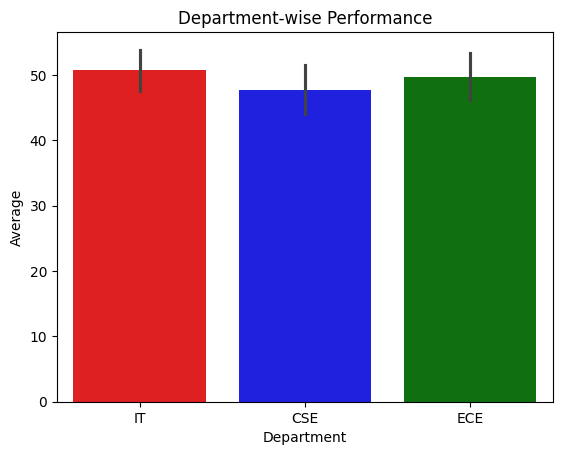

In [ ]:
plt.figure()
sns.barplot(
    x="Department",
    y="Average",
    hue="Department",
    data=df,
    palette=["red", "blue", "green"]
)
plt.title("Department-wise Performance")
plt.show()

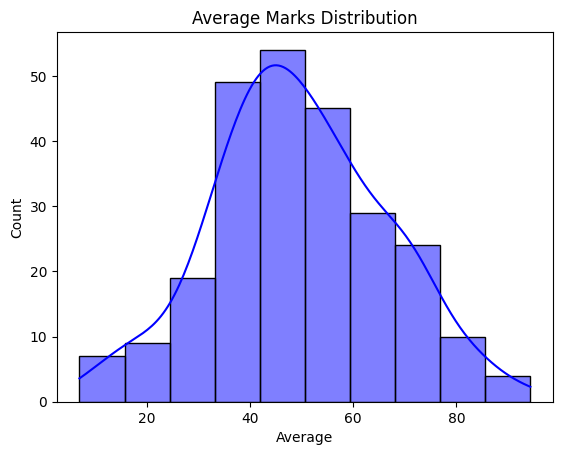

In [ ]:
plt.figure()
sns.histplot(df["Average"], bins=10, kde=True, color="blue")
plt.title("Average Marks Distribution")
plt.show()

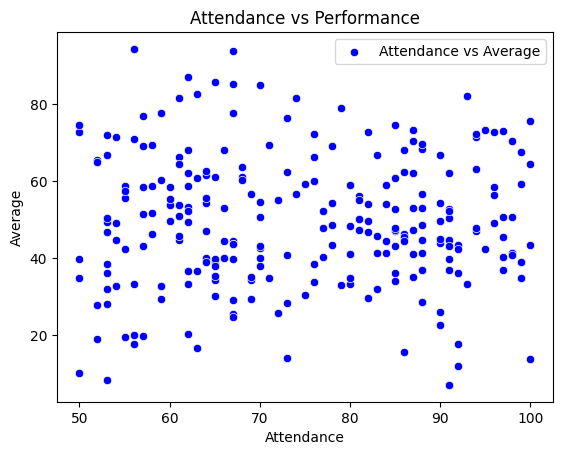

In [ ]:
plt.figure()
sns.scatterplot(
    x="Attendance",
    y="Average",
    data=df,
    color="blue",
    label="Attendance vs Average"
)
plt.title("Attendance vs Performance")
plt.legend()
plt.show()

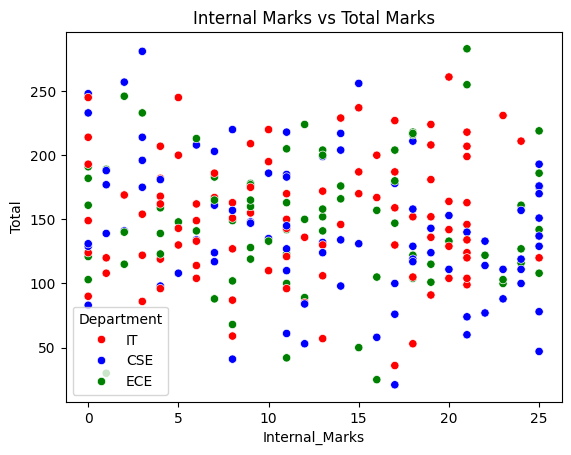

In [ ]:
plt.figure()
sns.scatterplot(
    x="Internal_Marks",
    y="Total",
    hue="Department",
    data=df,
    palette=["red", "blue", "green"]
)
plt.title("Internal Marks vs Total Marks")
plt.show()

In [ ]:
df.to_csv("student_data.csv", index=False)

print("✅ File saved successfully!")

✅ File saved successfully!
